<a href="https://colab.research.google.com/github/Akshat0175/Akshat-Agrawal-Porfolio/blob/main/Weather_Prdiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving BD_weather.csv to BD_weather (1).csv
GPU Available: []


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8180 - loss: 0.3872 - val_accuracy: 0.8289 - val_loss: 0.3640
Epoch 2/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8297 - loss: 0.3627 - val_accuracy: 0.8309 - val_loss: 0.3629
Epoch 3/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8307 - loss: 0.3610 - val_accuracy: 0.8308 - val_loss: 0.3614
Epoch 4/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8310 - loss: 0.3617 - val_accuracy: 0.8299 - val_loss: 0.3612
Epoch 5/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8309 - loss: 0.3612 - val_accuracy: 0.8313 - val_loss: 0.3605
Epoch 6/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8316 - loss: 0.3597 - val_accuracy: 0.8320 - val_loss: 0.3597
Epoch 7/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8309 - loss: 0.3591 - val_accuracy: 0.8312 - val_loss: 0.3604
Epoch 8/30
2720/2720 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8311 - loss: 0.3592 -

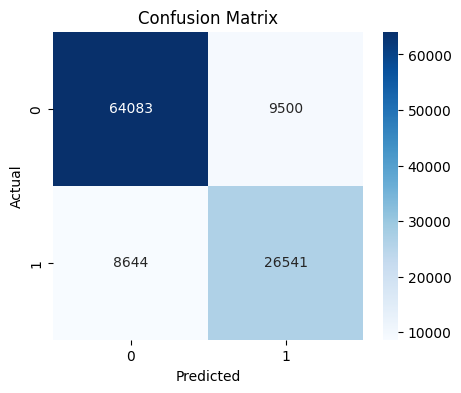


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88     73583
           1       0.74      0.75      0.75     35185

    accuracy                           0.83    108768
   macro avg       0.81      0.81      0.81    108768
weighted avg       0.83      0.83      0.83    108768



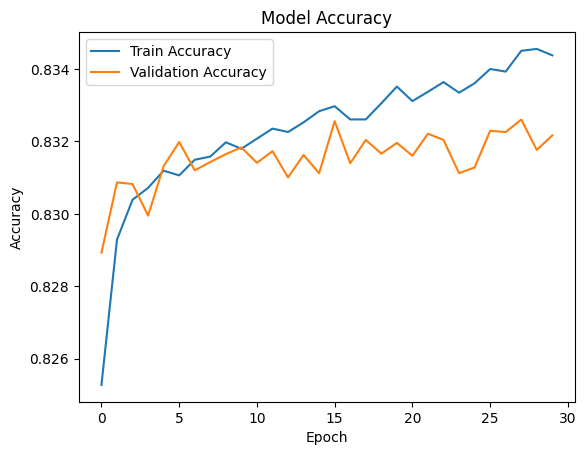

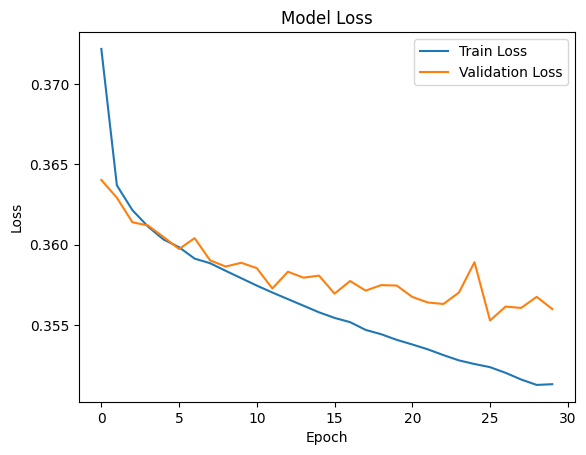

In [3]:

# 1️⃣ Import Libraries


from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

print("GPU Available:", tf.config.list_physical_devices('GPU'))


# 2️⃣ Load Dataset


df = pd.read_csv("BD_weather.csv")
df = df.dropna()

# Create Binary Target (Rain or No Rain)
df['Rain_Class'] = (df['Rainfall'] > 0).astype(int)

# Drop unnecessary column
df = df.drop("Station", axis=1)


# 3️⃣ Define Features & Target


X = df[['Year', 'Month', 'Day', 'Sunshine', 'Humidity', 'Temperature']]
y = df['Rain_Class']


# 4️⃣ Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 5️⃣ Feature Scaling


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 6️⃣ Build ANN Model


model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# 7️⃣ Early Stopping


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# 8️⃣ Train Model


history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)


# 9️⃣ Evaluate Model


loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)


# 🔟 Confusion Matrix


y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#
# 1️⃣1️⃣ Accuracy Graph


plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


# 1️⃣2️⃣ Loss Graph


plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()
